### Отчет по заданию: ДЗ 4

### Часть один

Выполним несколько сборок с разными k-mer значениями с шагом 10 с помощью Velvet.
- Файлы чтений: `7_S4_L001_R1_001.fastq` и `7_S4_L001_R2_001.fastq`

Создадим отдельное conda-окружение `velvet_env` и установим Velvet:


`conda create -n velvet_env`

`conda activate velvet_env`

`conda install -c bioconda velvet`
`

Напишем скрипт `run_velvet.slurm` для запуска 4 сборок с k-mer = 31, 41, 51, 61:

Запускаем `sbatch run_velvet.slurm`

Получаем:

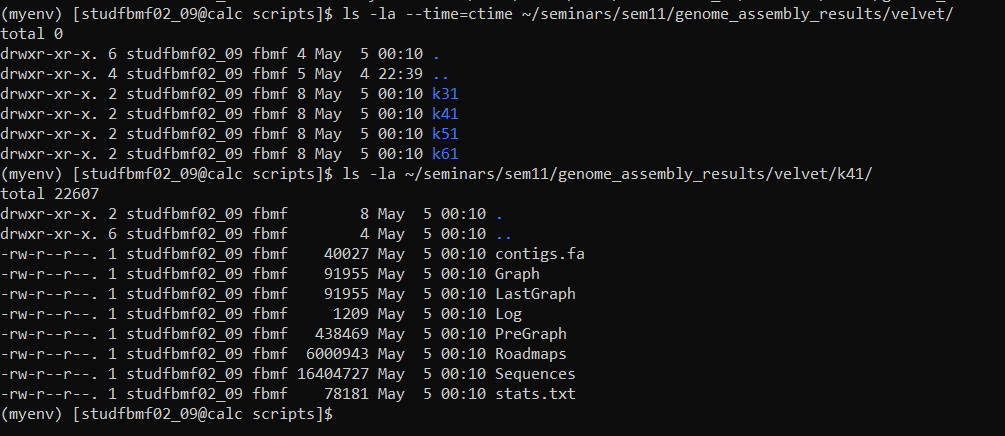

Т.е получили структуру папок:

### Часть 2

Сравним сборки Velvet и SPAdes с помощью QUAST

QUAST был установлен в `~/soft/` через pip:

`pip install --target ~/soft/ quast`

Для корректного сравнения (учитывая короткие контиги Velvet) QUAST запускался с пониженным порогом `--min-contig 200`.

Скрипт `run_quast_part2.slurm`:

Полученные результаты:

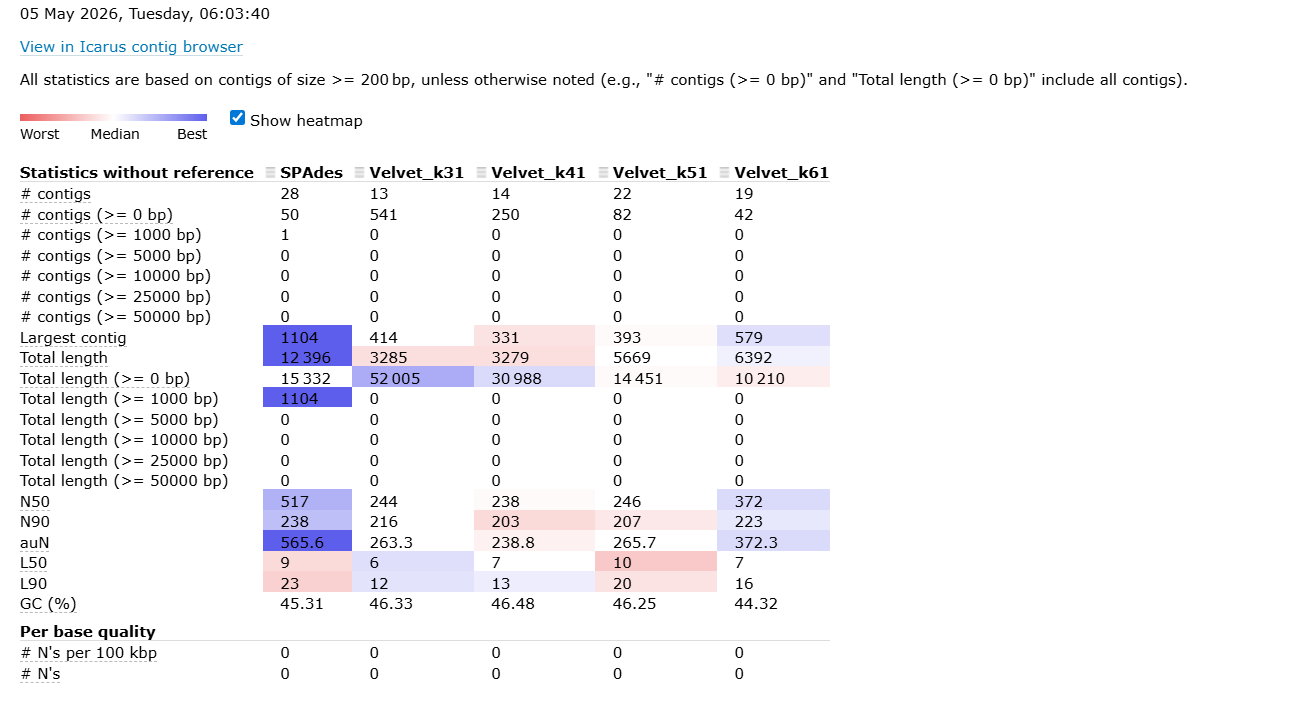

Наблюдения и выводы:

- SPAdes превосходит все сборки Velvet по ключевым метрикам:
   - Самый длинный контиг: 1104 bp vs 579 bp у Velvet_k61
   - Общая длина сборки: 12 396 bp vs 6 392 bp
   - N50: 517 bp vs 372 bp

 - Среди сборок Velvet лучшей оказалась k=61 (наибольшая длина контига 579 bp, лучший N50 372, наименьшее количество контигов — 42 при пороге 0 bp). k=31 даёт больше всего контигов (541), но они короткие.

- Все сборки показывают GC% в диапазоне 44-46%, что соответствует ожиданиям для вируса гриппа.

Таким образом, SPAdes является более эффективным ассемблером для данного набора данных, чем Velvet. Это объясняется тем, что SPAdes специально оптимизирован для сборки небольших геномов на коротких ридах Illumina. Среди сборок Velvet оптимальным значением k-mer является k=61

### Часть три
Улучшим сборку, изменив параметры SPAdes и Velvet, и сравним улучшенные версии со старыми.

Для улучшения Velvet были добавлены параметры:
- `-exp_cov auto` — автоматическое определение ожидаемого покрытия
- `-cov_cutoff 2` — отсечение контигов с покрытием ниже 2× (для удаления ошибочных)

k возьмем например 41

Скрипт `run_velvet_improved.slurm`:

Для улучшения SPAdes был использован флаг `--careful` (режим повышенной точности, исправление ошибок)

Скрипт `run_spades_improved.slurm`:

Для сравнения был запущен QUAST с порогом `--min-contig 200` для 4 сборок:
- SPAdes_old
- SPAdes_improved
- Velvet_k41_old (для одинакового k-mer)
- Velvet_improved

Скрипт `run_quast_final.slurm`:

Полученные результаты:

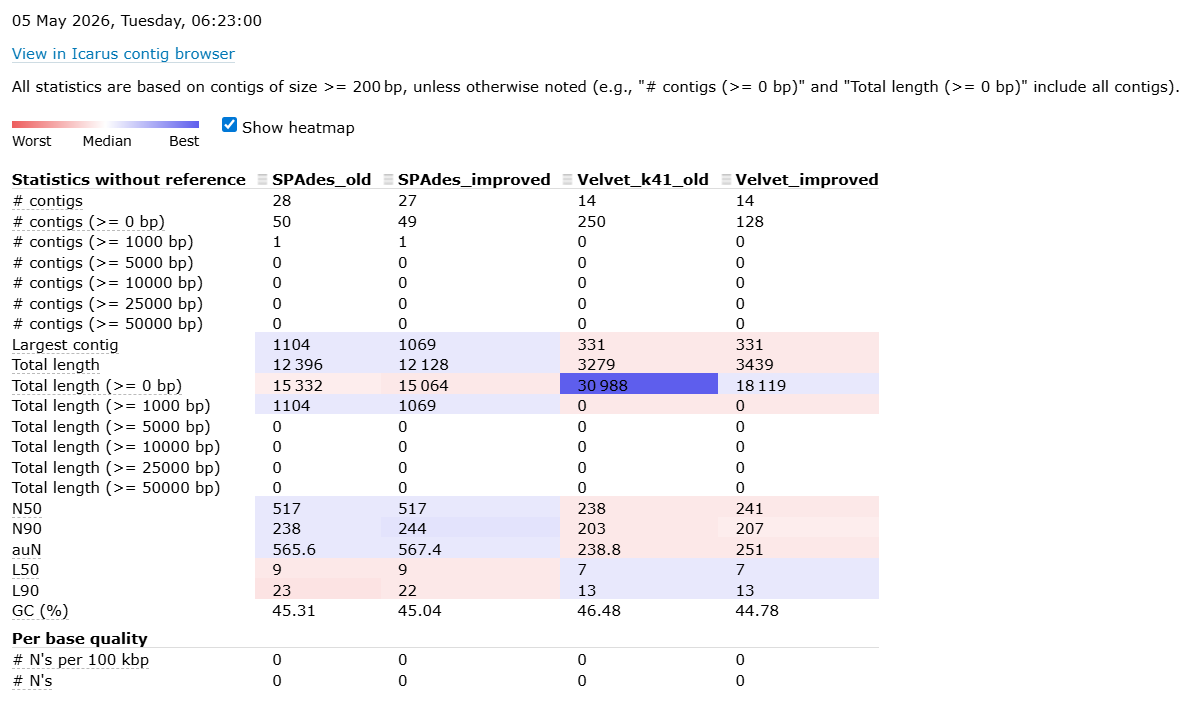

**Анализ результатов:**

**SPAdes: старая vs улучшенная**
- Количество контигов (≥0 bp): уменьшилось с 50 до 49
- Количество контигов: с 28 до 27
- Общая длина: с 12 396 до 12 128 (незначительное уменьшение)
- N50: остался без изменений (517)
- GC%: 45.31 → 45.04

Вывод по SPAdes: Флаг `--careful` дал небольшое улучшение — уменьшил количество контигов без потери качества. Отсутствие значительного улучшения объясняется тем, что исходные данные уже были высокого качества.

**Velvet: старая (k41) vs улучшенная (k41 + cov_cutoff)**
- Количество контигов (≥0 bp): значительно уменьшилось с 250 до 128 (отсечение коротких контигов)
- Количество контигов: осталось 14 (без изменений)
- Самый длинный контиг: 331 bp (без изменений)
- Общая длина: незначительно увеличилась с 3 279 до 3 439
- N50: незначительно вырос с 238 до 241

Вывод по Velvet: Параметры `-exp_cov auto` и `-cov_cutoff 2` не привели к значимому улучшению сборки. Отсечение контигов с покрытием ниже 2× удалило много коротких контигов (с 250 до 128 при пороге 0 bp), но не повлияло на самые длинные контиги. Для данных с высоким покрытием (как у вируса гриппа) такое отсечение не является эффективным.

**Выводы**

1. SPAdes `--careful` даёт небольшое, но положительное улучшение сборки (уменьшение числа контигов).

2. Velvet `-cov_cutoff` не улучшает сборку для данных с высоким покрытием — отсекает потенциально полезные контиги.

3. Лучшая сборка в целом — SPAdes_improved, так как у неё:
   - Наибольшая длина контига (1104 bp против 331 у Velvet)
   - Лучший N50 (517 против 241)
   - Наименьшее количество контигов при пороге 1000 bp
   - Наиболее реалистичный GC% (45.04)
